In [49]:
!pip install skshapes pyvista

## Imports

In [1]:
import os

os.environ["JAXTYPING_DISABLE"] = "1"

import skshapes as sks
import pyvista as pv
import numpy as np
import torch
import pyvista as pv
from IPython.display import Image

INTERACTIVE_RENDERING = False

## Prepare toy data

### Utils

In [2]:
# --- 2. 3D PHYSICS FUNCTION ---
def apply_3d_retraction(mesh, center, strength=0.5, sigma=4.0):
    """
    Apply a 3D retraction force towards a center point.
    Works on PyVista meshes.
    """
    points = np.array(mesh.points)
    vectors = points - center
    distances = np.linalg.norm(vectors, axis=1)
    
    # Avoid division by zero
    distances = np.where(distances == 0, 0.001, distances)
    unit_vectors = vectors / distances[:, None]
    
    # Gaussian-shaped displacement
    displacement = strength * distances * np.exp(-(distances**2) / (2 * sigma**2))
    
    # Apply deformation
    new_points = points - (unit_vectors * displacement[:, None])
    
    # Return a new mesh with updated points
    deformed_mesh = mesh.copy()
    deformed_mesh.points = new_points
    return deformed_mesh

# --- 3. SHAPE GENERATORS ---

def get_liver_3d():
    # Create a base sphere and scale it to look like a liver lobe
    liver = pv.Sphere(radius=5.0, phi_resolution=50, theta_resolution=50)
    liver = liver.scale([1.8, 1.0, 0.7], inplace=False)
    return liver

def get_vessel_3d(center_ablation):
    # Points de contrôle décalés pour contourner la zone d'ablation (rayon 2.2)
    # On s'assure que la distance au centre est toujours > 2.5
    path_points = np.array([
        [-3.0,  3.0,  0.5],  # En haut à gauche
        [ 0.0,  3.0,  0.0],  # Passe au dessus
        [ 3.0,  0.0, -1.0],  # Contourne par la droite
        [ 2.0, -3.0,  0.0],  # Redescend
        [-2.0, -4.0,  0.5]   # Sortie en bas
    ]) + center_ablation
    
    spline = pv.Spline(path_points, 50)
    return spline.tube(radius=0.25)

def validate_setup(liver, tumor, ablation, vessel):
    """
    Validation script to ensure anatomical constraints are met.
    """
    print("--- Geometry Validation Report ---")
    
    def check_inside(inner_mesh, outer_mesh):
        # Returns the percentage of points from inner_mesh contained in outer_mesh
        select = inner_mesh.select_enclosed_points(outer_mesh)
        return select['SelectedPoints'].view(bool).mean() * 100

    # 1. Vessel inside Liver
    v_in_l = check_inside(vessel, liver)
    print(f"Vessel inside Liver: {v_in_l:.1f}%")

    # 2. Vessel outside Ablation Zone
    v_in_a = check_inside(vessel, ablation)
    print(f"Vessel inside Ablation Zone: {v_in_a:.1f}% (Should be 0.0%)")

    # 3. Tumor inside Ablation Zone
    t_in_a = check_inside(tumor, ablation)
    print(f"Tumor inside Ablation Zone: {t_in_a:.1f}%")

    # 4. Ablation Zone inside Liver
    a_in_l = check_inside(ablation, liver)
    print(f"Ablation Zone inside Liver: {a_in_l:.1f}%")

    # Global status
    is_valid = (v_in_l == 100) and (v_in_a == 0) and (t_in_a == 100) and (a_in_l == 100)
    if is_valid:
        print("\n✅ SETUP VALID: All anatomical constraints are satisfied.")
    else:
        print("\n❌ SETUP INVALID: Please adjust positions or scales.")


### Create the data

In [3]:
# --- 4. PARAMÈTRES ET GÉNÉRATION ---
center_point = np.array([2.0, 1.0, 0.0])
tumor_radius, ablation_radius = 1.2, 2.2

# PRE-OP
liver_pre = get_liver_3d()
tumor_pre = pv.Sphere(radius=tumor_radius, center=center_point)
ablation_pre = pv.Sphere(radius=ablation_radius, center=center_point)
vessel_pre = get_vessel_3d(center_point)

# Run the validation
validate_setup(
    liver=liver_pre, 
    tumor=tumor_pre, 
    ablation=ablation_pre, 
    vessel=vessel_pre
)

# POST-OP
liver_post = apply_3d_retraction(liver_pre, center_point)
tumor_post = apply_3d_retraction(tumor_pre, center_point)
ablation_post = apply_3d_retraction(ablation_pre, center_point)
vessel_post = apply_3d_retraction(vessel_pre, center_point)

--- Geometry Validation Report ---
Vessel inside Liver: 100.0%
Vessel inside Ablation Zone: 0.0% (Should be 0.0%)
Tumor inside Ablation Zone: 100.0%
Ablation Zone inside Liver: 100.0%

✅ SETUP VALID: All anatomical constraints are satisfied.


### Visualisation

In [4]:
def render_plotter(plotter, base_filename, zoom=1):
    """
    Render all subplots in a plotter with different views and save screenshots.
    
    Parameters
    ----------
    plotter : pv.Plotter
        PyVista plotter with subplots
    base_filename : str
        Base filename for screenshots (without extension)
    zoom : float
        Zoom factor for the camera
    """
    if INTERACTIVE_RENDERING:
        plotter.view_xy()
        plotter.show()
    else:
        n_rows, n_cols = plotter.shape
        
        for view in ["xy", "yz", "xz"]:
            for i in range(n_rows):
                for j in range(n_cols):
                    plotter.camera.zoom(zoom)
                    plotter.subplot(i, j)
                    getattr(plotter, f"view_{view}")()
            filename = f"{base_filename}_{view}.png"
            plotter.camera.zoom(zoom)
            plotter.screenshot(filename)
            display(Image(filename))
        

2026-03-26 14:41:41.521 (   5.843s) [    7C8F1AC30740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-26 14:41:41.605 (   5.927s) [    7C8F1AC30740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x42e25880): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-26 14:41:41.640 (   5.962s) [    7C8F1AC30740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x44c00620): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

lib

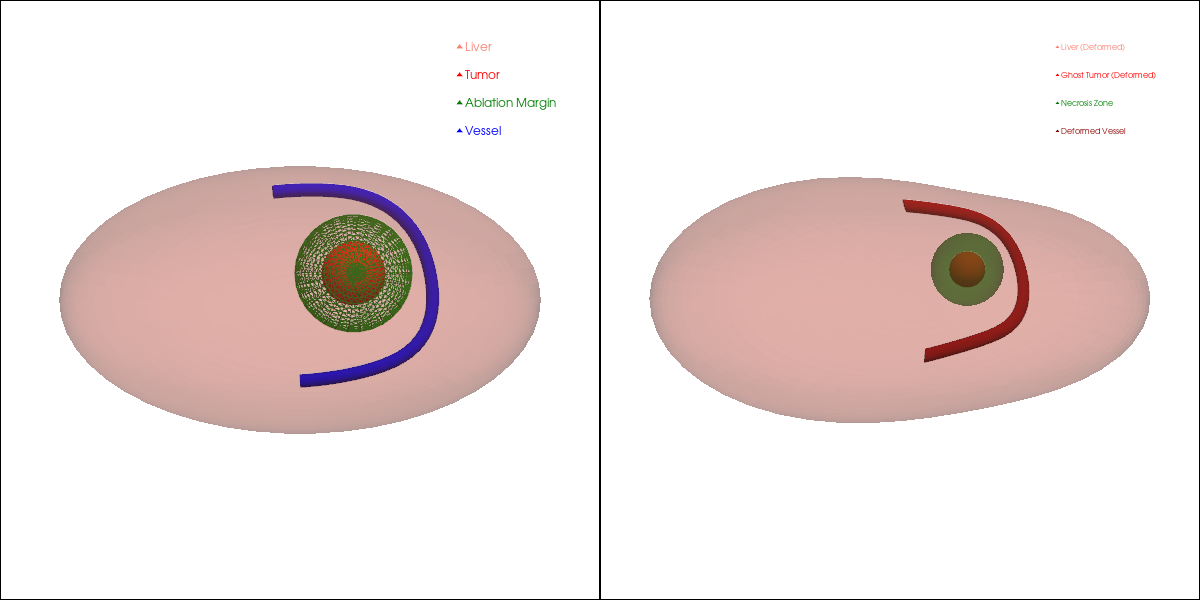

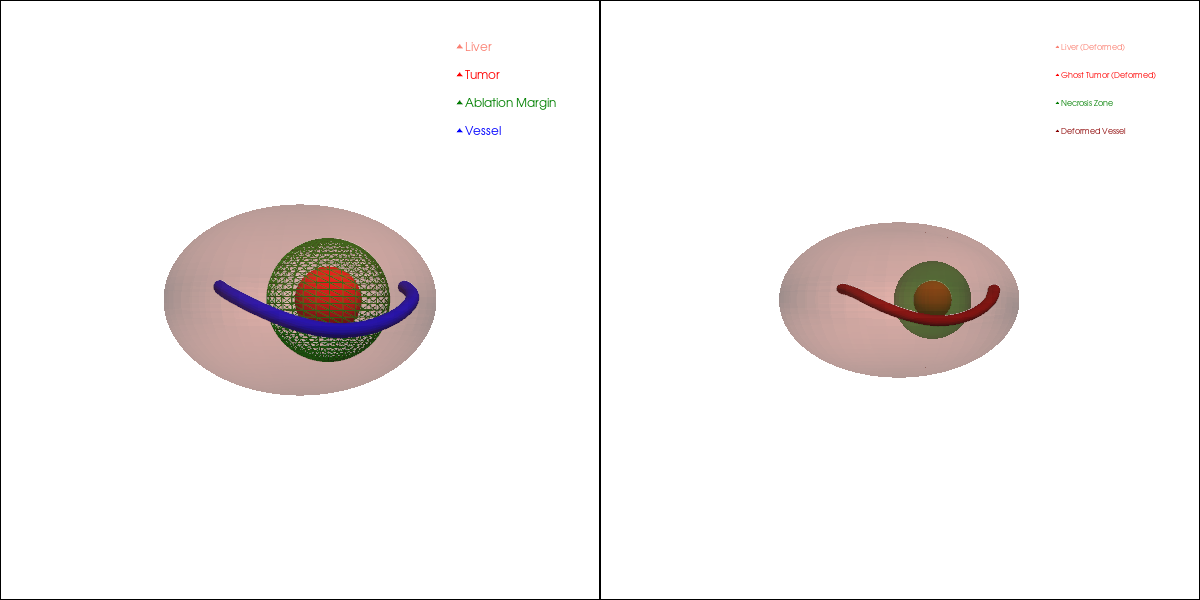

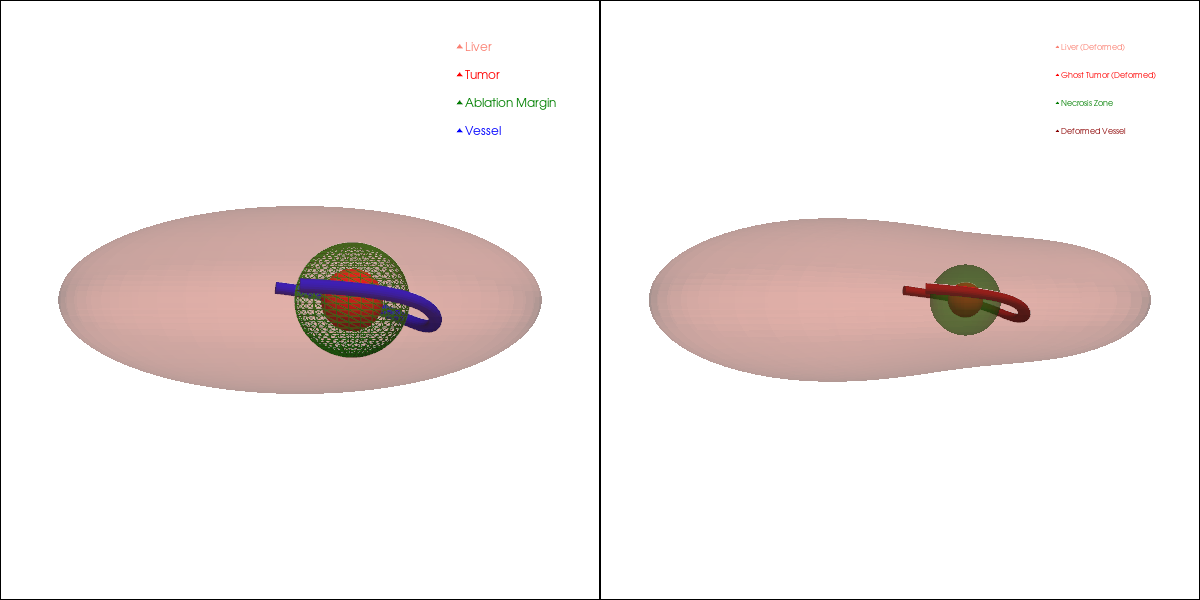

In [5]:
plotter = pv.Plotter(shape=(1, 2), off_screen=True, window_size=[1200, 600])

# --- SUBPLOT 0: PRE-OP ---
plotter.subplot(0, 0)
plotter.add_text(f"PRE-OP", font_size=12, color="white")
plotter.add_mesh(liver_pre, color="salmon", opacity=0.3, label="Liver")
plotter.add_mesh(tumor_pre, color="red", label="Tumor")
plotter.add_mesh(ablation_pre, color="green", style="wireframe", label="Ablation Margin")
plotter.add_mesh(vessel_pre, color="blue", label="Vessel")
plotter.add_legend(face=None) # Legend sans fond pour plus de clarté

# --- SUBPLOT 1: POST-OP ---
plotter.subplot(0, 1)
plotter.add_text(f"POST-OP", font_size=12, color="white")
plotter.add_mesh(liver_post, color="salmon", opacity=0.3, label="Liver (Deformed)")
plotter.add_mesh(tumor_post, color="red", label="Ghost Tumor (Deformed)")
plotter.add_mesh(ablation_post, color="green", opacity=0.5, label="Necrosis Zone")
plotter.add_mesh(vessel_post, color="darkred", label="Deformed Vessel")
plotter.add_legend(face=None)

render_plotter(plotter, f"registration_comparison")

## Registration with iModal

### Method 1

In [6]:
import func as f
import matplotlib.pyplot as plt

## Hyperparameters for plastic registration (iModal)

Use this section to understand what each parameter controls and how to tune it.

### Deformation model

- `sigma_local`: spatial scale of local deformation kernels.  
  Larger values spread local motion over wider neighborhoods (smoother, broader deformations).
- `nu_local`: regularization strength for local deformation.  
  Larger values penalize local bending more (stiffer local field, smaller displacements).
- `sigma_global`: spatial scale of global deformation kernels.  
  Larger values produce more coherent global motion.
- `nu_global`: regularization strength for global deformation.  
  Larger values make the global field stiffer and reduce overall deformation.
- `lamb`: weight of deformation penalty versus data attachment term.  
  Larger values favor smoother/smaller deformations; smaller values allow stronger fit to target.

### Optimization

- `lbfgs_max_iter`: maximum LBFGS iterations.  
  Increase if loss has not stabilized yet.
- `lbfgs_max_eval` (optional): maximum closure evaluations.  
  Useful when line search evaluates many times per iteration.
- `lbfgs_history_size` (optional): number of past updates stored by LBFGS.  
  Larger can improve convergence quality but uses more memory.
- `lbfgs_line_search_fn` (optional): line-search strategy (e.g., `'strong_wolfe'`).  
  Can improve stability when loss oscillates.
- `lbfgs_tolerance_grad`: stopping threshold on gradient norm.  
  Smaller values require tighter convergence.
- `lbfgs_tolerance_change`: stopping threshold on parameter/loss change.  
  Smaller values require finer convergence before stopping.

### Runtime and reproducibility

- `device`: compute backend (`'cuda'` or `'cpu'`).
- `show_progress`: display optimization progress bar/logs.
- `chunk_size_varifold`, `chunk_size_varifold_y`: chunk sizes for memory/performance trade-off in varifold computations.  
  Smaller values reduce memory usage, larger values are usually faster.
- `random_seed`: seed for reproducible stochastic steps/sampling.
- `clear_cuda_cache`: clears CUDA cache to reduce fragmentation between runs.

### Quick tuning guide

- **Too little deformation**: decrease `nu_global`, `nu_local`, and/or `lamb`; increase `lbfgs_max_iter`.
- **Too much/unstable deformation**: increase `nu_global` and `lamb`; optionally increase `nu_local`.
- **Noisy local warps**: increase `sigma_local` and/or `nu_local`.
- **Out-of-memory on GPU**: reduce `chunk_size_varifold` and `chunk_size_varifold_y`.

registration_imodal (LBFGS):   0%|          | 0/600 [00:00<?, ?it/s]/teamspace/studios/this_studio/2025-Projet-radiologie-interventionnelle/imodal_git/imodal/Utilities/meshutils.py:616: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  normals = 0.5 * torch.cross(v1 - v0, v2 - v0)
registration_imodal (LBFGS):   0%|          | 3/600 [00:03<09:51,  1.01it/s, calls=3, loss=2.4995e+02]

registration_imodal (LBFGS):   3%|▎         | 16/600 [00:14<08:38,  1.13it/s, calls=16, loss=2.4946e+02]


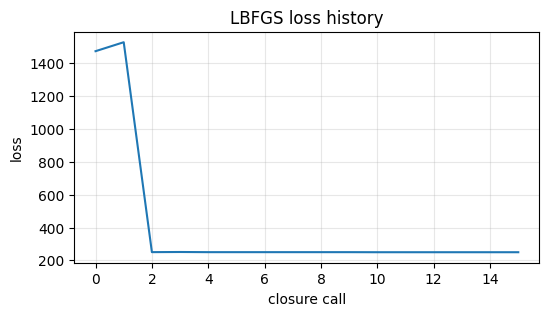

In [7]:
parameters = {
    'sigma_local': 0.3,
    'nu_local': 0.002,
    'sigma_global': 2.0,
    'nu_global': 0.08,
    'lamb': 0.01,
    'device': 'cuda',
    'show_progress': True,
    'chunk_size_varifold': 64,
    'chunk_size_varifold_y': 4096,
    'random_seed': 0,
    'clear_cuda_cache': True,
    'lbfgs_max_iter': 200,
    'lbfgs_max_eval': 600,
    'lbfgs_history_size': 50,
    "lbfgs_tolerance_grad": 1e-10,
    "lbfgs_tolerance_change": 1e-12,
}

liver_res, vessel_res, abla_res, force_loc, force_glob, historique_loss = f.registration_imodal_from_mesh(
    liver_pre=liver_pre,
    liver_post=liver_post,
    vessels_pre=[vessel_pre],
    vessels_post=[vessel_post],
    ablation_zone_post=ablation_post,
    params=parameters,
    dtype=torch.float32
    )

plt.figure(figsize=(6, 3))
plt.plot(historique_loss)
plt.title("LBFGS loss history")
plt.xlabel("closure call")
plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.show()


In [8]:
# --- Visual reconstruction on toy meshes (single vessel) ---
# triangulate().clean() exactly reproduces what registration_imodal_from_mesh
# does internally, ensuring point ordering is consistent with liver_res.
liver_post_src_pts = np.asarray(liver_post.triangulate().clean().points, dtype=np.float64)

liver_res_mesh = liver_post.triangulate().clean().copy()
liver_res_mesh.points = np.asarray(liver_res, dtype=np.float64)

abla_res_mesh = ablation_post.triangulate().clean().copy()
abla_res_mesh.points = np.asarray(abla_res, dtype=np.float64)

vessel_res_meshes = []
for vessel_post_i, vessel_res_i in zip([vessel_post], vessel_res):
    vessel_mesh_i = vessel_post_i.triangulate().clean().copy()
    vessel_mesh_i.points = np.asarray(vessel_res_i, dtype=np.float64)
    vessel_res_meshes.append(vessel_mesh_i)

In [9]:
from scipy.spatial import cKDTree

def warp_points_idw(full_points, control_src, control_dst, k=8, power=2.0, eps=1e-8):
    """Warp dense points using inverse-distance-weighted interpolation from control displacements.

    Parameters
    ----------
    full_points : array-like, shape (M, 3)
        Points to deform.
    control_src : array-like, shape (K, 3)
        Source control points.
    control_dst : array-like, shape (K, 3)
        Destination control points.
    k : int
        Number of nearest controls used per point.
    power : float
        Inverse distance exponent.
    eps : float
        Numerical stabilization term for very small distances.

    Returns
    -------
    numpy.ndarray
        Warped points with shape (M, 3).
    """
    full_points = np.asarray(full_points, dtype=np.float64)
    control_src = np.asarray(control_src, dtype=np.float64)
    control_dst = np.asarray(control_dst, dtype=np.float64)
    disp_ctrl = control_dst - control_src
    if control_src.shape[0] == 0:
        return full_points.copy()
    k_eff = min(max(1, int(k)), control_src.shape[0])
    tree = cKDTree(control_src)
    d, idx = tree.query(full_points, k=k_eff, workers=-1)
    if k_eff == 1:
        d = d[:, None]
        idx = idx[:, None]
    w = 1.0 / np.maximum(d, eps) ** float(power)
    w = w / np.maximum(w.sum(axis=1, keepdims=True), eps)
    disp = (disp_ctrl[idx] * w[..., None]).sum(axis=1)
    return full_points + disp

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-26 14:41:59.077 (  23.399s) [    7C8F1AC30740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x6050f6a0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-26 14:41:59.099 (  23.421s) [    7C8F1AC30740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x5e7fa4d0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permissio

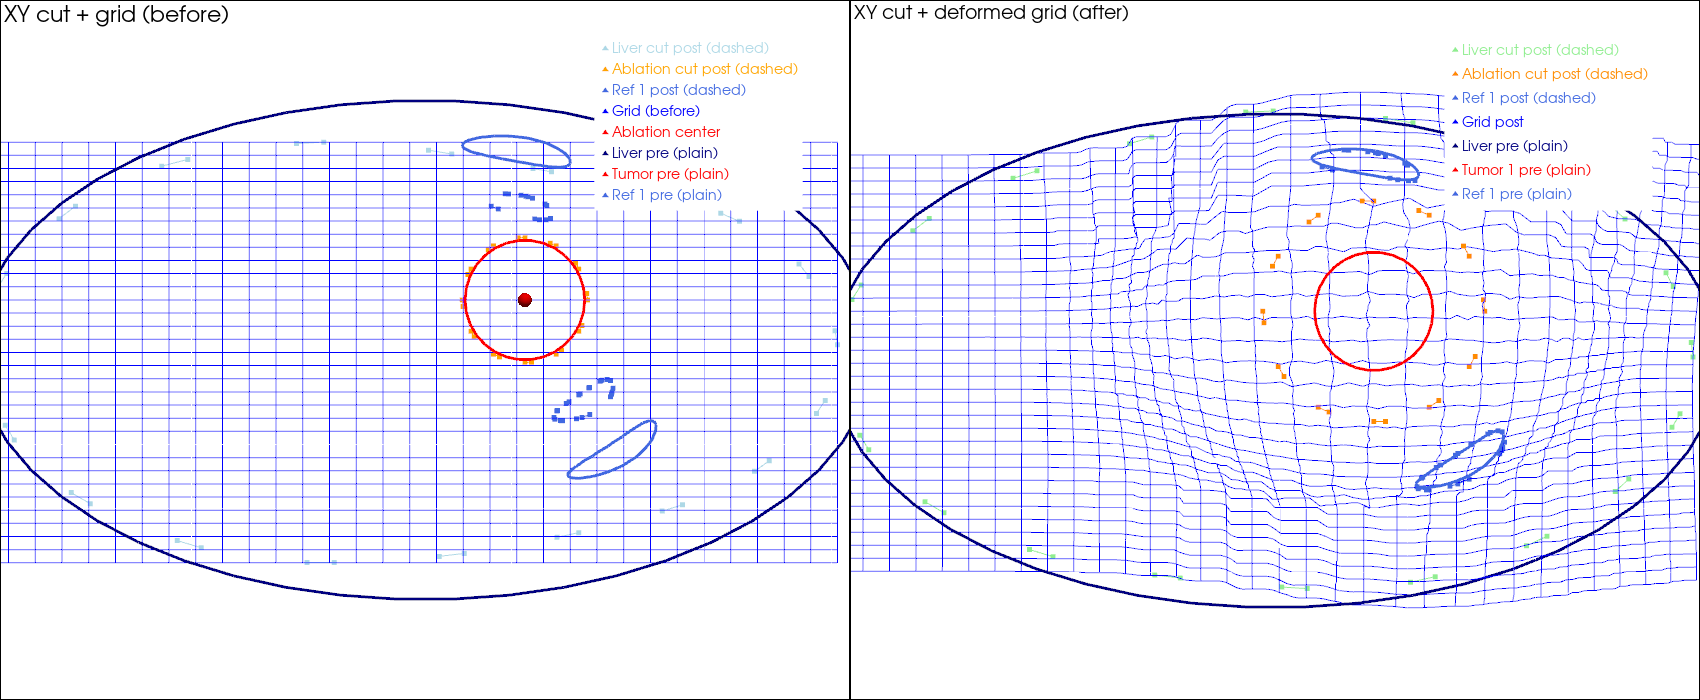

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-26 14:42:00.083 (  24.405s) [    7C8F1AC30740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x6029d550): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-26 14:42:00.103 (  24.425s) [    7C8F1AC30740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x637dfb20): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permissio

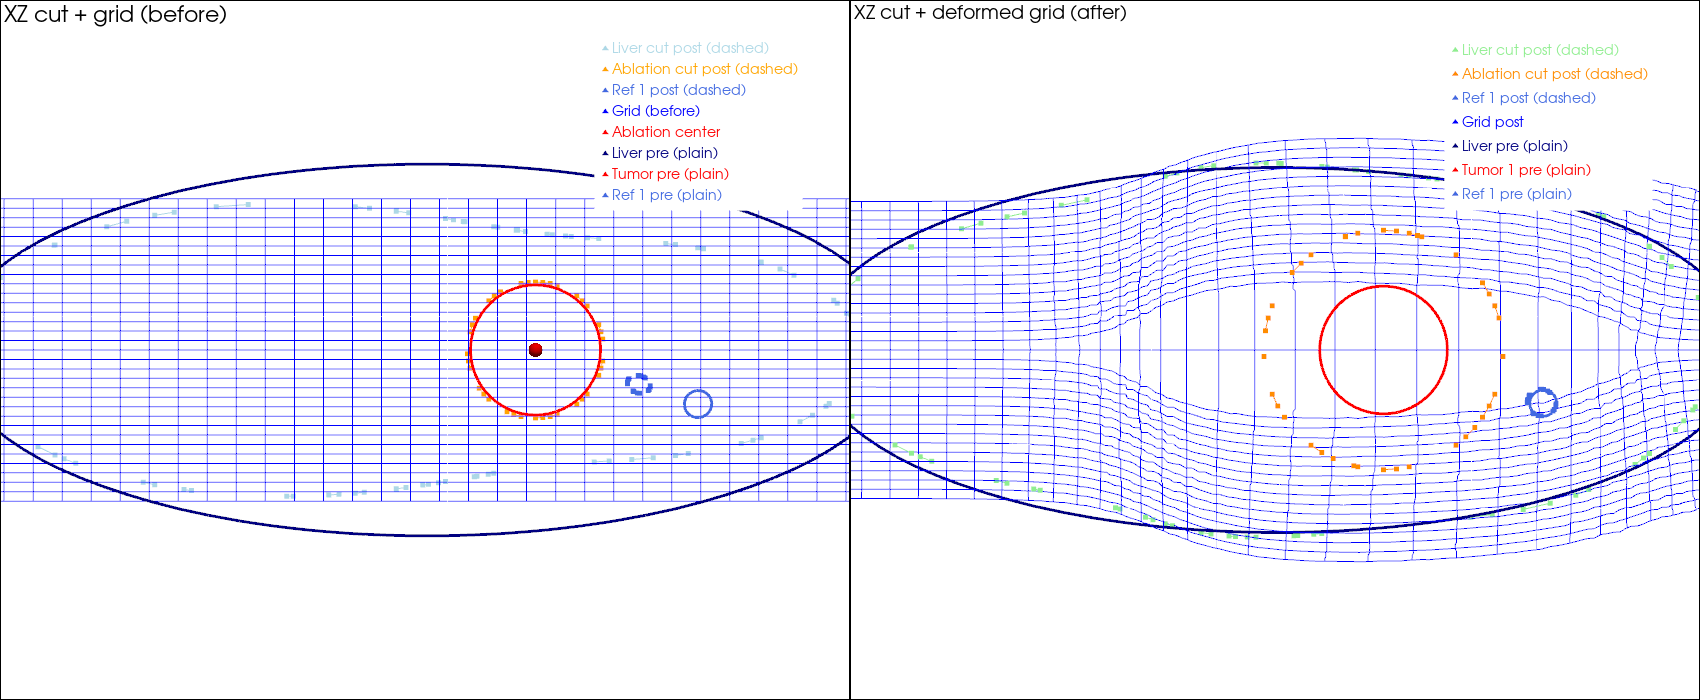

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-26 14:42:01.260 (  25.582s) [    7C8F1AC30740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x6d1f7eb0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-26 14:42:01.280 (  25.602s) [    7C8F1AC30740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x6ce8a670): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permissio

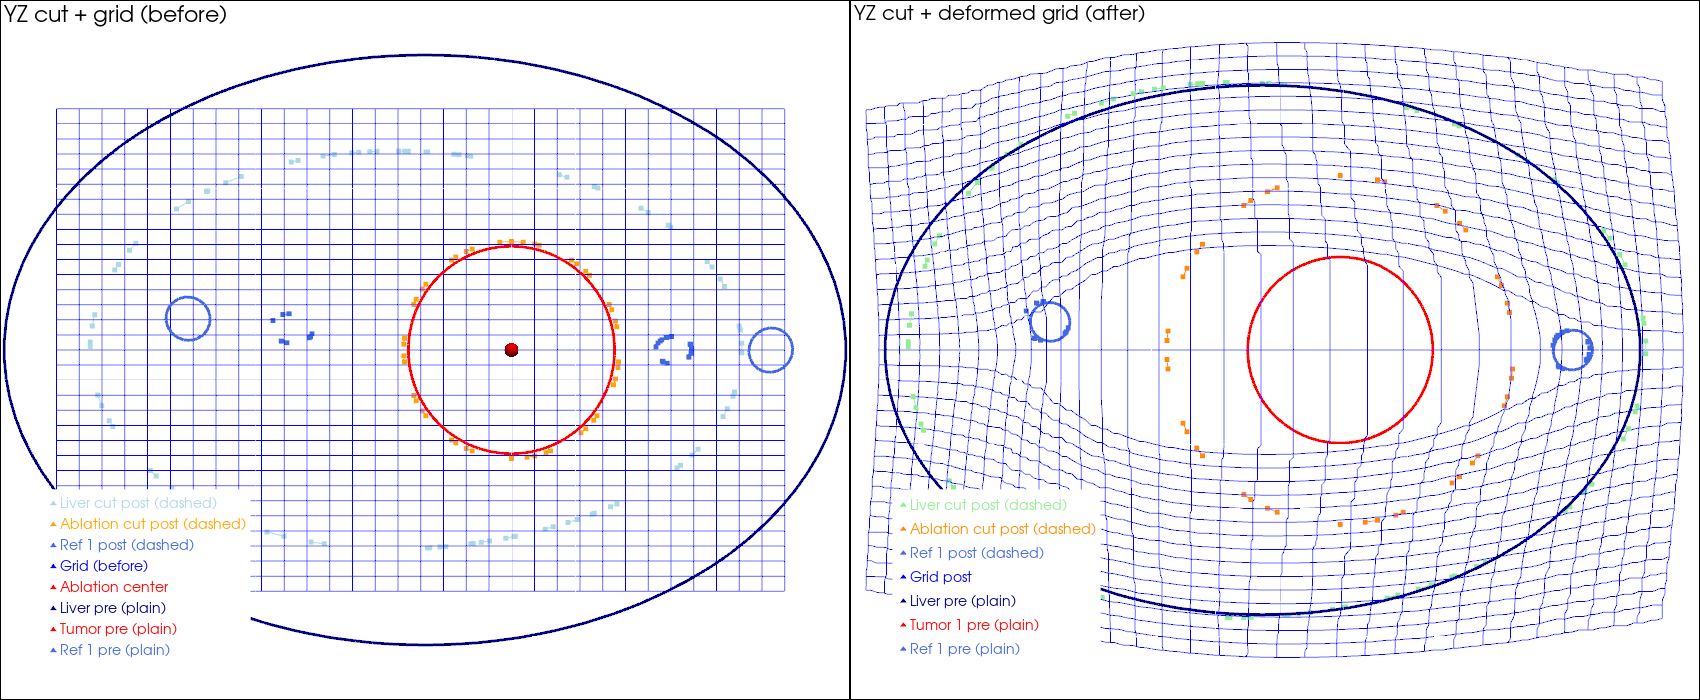

In [10]:

# --- Grid deformation visualization after plastic registration (all 3 planes) ---
def make_plane_grid(bounds, n_lines=11, n_samples=120, plane="xy", frac=0.5, center=None):
    """Create a regular line grid on a plane inside the bounding box."""
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    lines = []

    if plane == "xy":
        if center is None:
            z0 = zmin + frac * (zmax - zmin)
        else:
            z0 = float(np.clip(center[2], zmin, zmax))
        ys = np.linspace(ymin, ymax, n_lines)
        xs = np.linspace(xmin, xmax, n_lines)
        x_samples = np.linspace(xmin, xmax, n_samples)
        y_samples = np.linspace(ymin, ymax, n_samples)

        for y in ys:
            pts = np.column_stack([x_samples, np.full_like(x_samples, y), np.full_like(x_samples, z0)])
            lines.append(pv.lines_from_points(pts, close=False))
        for x in xs:
            pts = np.column_stack([np.full_like(y_samples, x), y_samples, np.full_like(y_samples, z0)])
            lines.append(pv.lines_from_points(pts, close=False))

    elif plane == "xz":
        if center is None:
            y0 = ymin + frac * (ymax - ymin)
        else:
            y0 = float(np.clip(center[1], ymin, ymax))
        zs = np.linspace(zmin, zmax, n_lines)
        xs = np.linspace(xmin, xmax, n_lines)
        x_samples = np.linspace(xmin, xmax, n_samples)
        z_samples = np.linspace(zmin, zmax, n_samples)

        for z in zs:
            pts = np.column_stack([x_samples, np.full_like(x_samples, y0), np.full_like(x_samples, z)])
            lines.append(pv.lines_from_points(pts, close=False))
        for x in xs:
            pts = np.column_stack([np.full_like(z_samples, x), np.full_like(z_samples, y0), z_samples])
            lines.append(pv.lines_from_points(pts, close=False))

    elif plane == "yz":
        if center is None:
            x0 = xmin + frac * (xmax - xmin)
        else:
            x0 = float(np.clip(center[0], xmin, xmax))
        zs = np.linspace(zmin, zmax, n_lines)
        ys = np.linspace(ymin, ymax, n_lines)
        y_samples = np.linspace(ymin, ymax, n_samples)
        z_samples = np.linspace(zmin, zmax, n_samples)

        for z in zs:
            pts = np.column_stack([np.full_like(y_samples, x0), y_samples, np.full_like(y_samples, z)])
            lines.append(pv.lines_from_points(pts, close=False))
        for y in ys:
            pts = np.column_stack([np.full_like(z_samples, x0), np.full_like(z_samples, y), z_samples])
            lines.append(pv.lines_from_points(pts, close=False))
    else:
        raise ValueError("plane must be one of: 'xy', 'xz', 'yz'")

    return lines

def points_near_plane(points, origin, normal, tol):
    """Return points within distance tol from a plane."""
    pts = np.asarray(points, dtype=np.float64)
    n = np.asarray(normal, dtype=np.float64)
    n = n / (np.linalg.norm(n) + 1e-12)
    d = np.abs((pts - origin) @ n)
    keep = d <= tol
    if not np.any(keep):
        return pv.PolyData(np.empty((0, 3), dtype=np.float64))
    return pv.PolyData(pts[keep])

def to_dashed_lines(poly, keep_segments=1, skip_segments=4, phase=0):
    """Approximate dashed rendering by keeping configurable segment patterns.

    Parameters
    ----------
    poly : pv.PolyData
        Input polyline mesh.
    keep_segments : int
        Number of consecutive segments to keep (dash length in segments).
    skip_segments : int
        Number of consecutive segments to skip (gap length in segments).
    phase : int
        Segment offset applied to the dash cycle.
    """
    if poly is None or poly.n_points == 0 or poly.lines.size == 0:
        return poly

    keep_segments = max(1, int(keep_segments))
    skip_segments = max(0, int(skip_segments))
    period = keep_segments + skip_segments
    if period <= 0:
        return poly
    phase = int(phase) % period

    pts = poly.points
    conn = poly.lines
    out_pts = []
    out_lines = []
    seg_idx_global = 0
    i = 0
    while i < len(conn):
        n = int(conn[i])
        ids = conn[i + 1:i + 1 + n]
        for j in range(n - 1):
            in_dash = ((seg_idx_global + phase) % period) < keep_segments
            if in_dash:
                p0 = pts[ids[j]]
                p1 = pts[ids[j + 1]]
                idx0 = len(out_pts)
                out_pts.append(p0)
                out_pts.append(p1)
                out_lines.extend([2, idx0, idx0 + 1])
            seg_idx_global += 1
        i += n + 1
    if len(out_pts) == 0:
        return pv.PolyData(np.empty((0, 3), dtype=np.float64))
    dashed = pv.PolyData(np.asarray(out_pts, dtype=np.float64))
    dashed.lines = np.asarray(out_lines, dtype=np.int64)
    return dashed

def add_mesh_if_not_empty(plotter, mesh, **kwargs):
    """Add mesh only if it contains points (avoids empty-slice crashes)."""
    if mesh is None:
        return
    if hasattr(mesh, "n_points") and mesh.n_points == 0:
        return
    plotter.add_mesh(mesh, **kwargs)

# Center from merged ablation
ablation_center = np.asarray(ablation_post.points, dtype=np.float64).mean(axis=0)

# Geometry scale for display
xmin, xmax, ymin, ymax, zmin, zmax = liver_post.bounds
diag = np.linalg.norm([xmax - xmin, ymax - ymin, zmax - zmin])
point_tol = 0.01 * diag

planes = [
    ("xy", (0, 0, 1), "xy"),
    ("xz", (0, 1, 0), "xz"),
    ("yz", (1, 0, 0), "yz"),
]

# Pre-registration surfaces/cuts (POST state before deformation)
liver_surface_before = liver_post.extract_surface().triangulate().clean()
ablation_surface_before = ablation_post.extract_surface().triangulate().clean()
reference_surfaces_before = [
    vessel_post.extract_surface().triangulate().clean(),
]

# Post-registration surfaces/cuts (fallback to pre if not available)
liver_surface_after = (
    liver_res_mesh.extract_surface().triangulate().clean()
    if 'liver_res_mesh' in globals() else liver_surface_before
)
ablation_surface_after = (
    abla_res_mesh.extract_surface().triangulate().clean()
    if 'abla_res_mesh' in globals() else ablation_surface_before
)
reference_surfaces_after = (
    [m.extract_surface().triangulate().clean() for m in vessel_res_meshes]
    if ('vessel_res_meshes' in globals() and len(vessel_res_meshes) > 0) else reference_surfaces_before
)

# PRE-op reference set to overlay on both panels (plain lines)
liver_surface_pre = liver_pre.extract_surface().triangulate().clean()
tumor_surfaces_pre = [
    tumor_pre.extract_surface().triangulate().clean(),
]
reference_meshes_pre = [vessel_pre]

reference_colors = ["royalblue", "cyan", "magenta"]

legend_params = [
    {
        'face': None,
        'bcolor': 'white',
        'border': True,
        'loc': 'upper right',
        'size': (0.25, 0.25),
    },
    {
        'face': None,
        'bcolor': 'white',
        'border': True,
        'loc': 'upper right',
        'size': (0.25, 0.25),
    },
    {
        'face': None,
        'bcolor': 'white',
        'border': True,
        'loc': 'lower left',
        'size': (0.25, 0.25),
    }
]

for (plane_name, normal, view_name), legend_param in zip(planes, legend_params):
    # Build grid on this plane centered at ablation center
    grid_before = make_plane_grid(
        liver_post.bounds,
        n_lines=33,
        n_samples=140,
        plane=plane_name,
        center=ablation_center,
    )
    grid_after = [
        pv.lines_from_points(
            warp_points_idw(line.points, liver_post_src_pts, liver_res, k=8, power=2.0),
            close=False
        )
        for line in grid_before
    ]

    # Cuts for this plane
    liver_cut_before = liver_surface_before.slice(normal=normal, origin=ablation_center)
    ablation_cut_before = ablation_surface_before.slice(normal=normal, origin=ablation_center)
    liver_cut_after = liver_surface_after.slice(normal=normal, origin=ablation_center)
    ablation_cut_after = ablation_surface_after.slice(normal=normal, origin=ablation_center)

    # PRE overlays (plain lines) — used on both subplots
    liver_cut_pre = liver_surface_pre.slice(normal=normal, origin=ablation_center)
    tumor_cuts_pre = [m.slice(normal=normal, origin=ablation_center) for m in tumor_surfaces_pre]
    ref_cuts_pre = [
        m.extract_surface().triangulate().clean().slice(normal=normal, origin=ablation_center)
        for m in reference_meshes_pre
    ]

    plotter = pv.Plotter(shape=(1, 2), off_screen=True, window_size=[1700, 700])

    # BEFORE: post cuts dashed + pre cuts plain
    plotter.subplot(0, 0)
    plotter.add_text(f"{plane_name.upper()} cut + grid (before)", font_size=11, color="black")
    add_mesh_if_not_empty(plotter, to_dashed_lines(liver_cut_before), color="lightblue", line_width=1, label="Liver cut post (dashed)")
    add_mesh_if_not_empty(plotter, to_dashed_lines(ablation_cut_before), color="orange", line_width=1, label="Ablation cut post (dashed)")
    for idx, (ref_surface, ref_color) in enumerate(zip(reference_surfaces_before, reference_colors), start=1):
        ref_cut = ref_surface.slice(normal=normal, origin=ablation_center)
        add_mesh_if_not_empty(plotter, to_dashed_lines(ref_cut), color=ref_color, line_width=1, label=f"Ref {idx} post (dashed)")
    for i, line in enumerate(grid_before):
        plotter.add_mesh(line, color="blue", line_width=1.0, label="Grid (before)" if i == 0 else None)
    plotter.add_mesh(
        pv.PolyData(ablation_center[None, :]),
        color="red",
        point_size=14,
        render_points_as_spheres=True,
        label="Ablation center"
    )
    # PRE overlays (plain)
    add_mesh_if_not_empty(plotter, liver_cut_pre, color="navy", line_width=3, label="Liver pre (plain)")
    add_mesh_if_not_empty(plotter, tumor_cuts_pre[0], color="red", line_width=3, label="Tumor pre (plain)")
    for i, (cut, color) in enumerate(zip(ref_cuts_pre, reference_colors), start=1):
        add_mesh_if_not_empty(plotter, cut, color=color, line_width=3, label=f"Ref {i} pre (plain)")
    getattr(plotter, f"view_{view_name}")()
    plotter.camera.zoom(1.5)
    plotter.add_legend(**legend_param)

    # AFTER: post-deformed dashed + pre plain
    plotter.subplot(0, 1)
    plotter.add_text(f"{plane_name.upper()} cut + deformed grid (after)", font_size=11, color="black")
    add_mesh_if_not_empty(plotter, to_dashed_lines(liver_cut_after), color="lightgreen", line_width=1, label="Liver cut post (dashed)")
    add_mesh_if_not_empty(plotter, to_dashed_lines(ablation_cut_after), color="darkorange", line_width=1, label="Ablation cut post (dashed)")
    for idx, (ref_surface, ref_color) in enumerate(zip(reference_surfaces_after, reference_colors), start=1):
        ref_cut = ref_surface.slice(normal=normal, origin=ablation_center)
        add_mesh_if_not_empty(
            plotter,
            to_dashed_lines(ref_cut),
            color=ref_color,
            line_width=1,
            label=f"Ref {idx} post (dashed)"
        )
    for i, line in enumerate(grid_after):
        add_mesh_if_not_empty(plotter, line, color="blue", line_width=1.0, label="Grid post" if i == 0 else None)

    # PRE overlays (plain)
    add_mesh_if_not_empty(plotter, liver_cut_pre, color="navy", line_width=3, label="Liver pre (plain)")
    add_mesh_if_not_empty(plotter, tumor_cuts_pre[0], color="red", line_width=3, label="Tumor 1 pre (plain)")
    for i, (cut, color) in enumerate(zip(ref_cuts_pre, reference_colors), start=1):
        add_mesh_if_not_empty(plotter, cut, color=color, line_width=3, label=f"Ref {i} pre (plain)")

    getattr(plotter, f"view_{view_name}")()
    plotter.camera.zoom(1.5)
    plotter.add_legend(**legend_param)

    if INTERACTIVE_RENDERING:
        plotter.show()
    else:
        filename = f"orthogonal_cut_grid_{plane_name}.png"
        plotter.screenshot(filename)
        display(Image(filename))
